In [1]:
import cmat
from matplotlib import pyplot as plt
import numpy as np
from multiprocessing import get_context
from pathlib import Path
from types import SimpleNamespace
import pandas as pd
import os

SMOKE_MODE = os.environ.get('CMAT_NOTEBOOK_SMOKE') == '1'
NOTEBOOK_DATA_DIR = Path('./data')

def load_cached_notebook_planet(planet_name):
    tc_data = pd.read_csv(NOTEBOOK_DATA_DIR / planet_name / 'tc_data.csv')
    prop_row = pd.read_csv(NOTEBOOK_DATA_DIR / planet_name / 'prop_data.csv').iloc[0]
    prop = [{
        key: float(prop_row[key])
        for key in ('orbital_distance', 'orbital_period', 'Mp', 'Ms', 'Rs', 'Rp')
    }]

    class CachedNotebookPlanet(SimpleNamespace):
        def plot_ttv_re(self):
            fig, ax = plt.subplots(figsize=(4, 3.2), dpi=200)
            ax.errorbar(self.epochs, self.ttv_mcmc, yerr=self.ttv_err, fmt='o')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('residual (s)')
            return fig, ax

    return CachedNotebookPlanet(
        planet_name=planet_name,
        datadir=str(NOTEBOOK_DATA_DIR),
        epochs=tc_data['epochs'].to_numpy(dtype=int),
        ttv_mcmc=tc_data['ttv_mcmc'].to_numpy(dtype=float),
        ttv_mcmc_raw=tc_data['ttv_mcmc'].to_numpy(dtype=float),
        ttv_err=tc_data['ttv_err'].to_numpy(dtype=float),
        prop=prop,
    )

# 1. Set Target

In [2]:
planet_name = 'WASP-44 b'
if SMOKE_MODE:
    planet = load_cached_notebook_planet(planet_name)
else:
    planet = cmat.Fitlpf(planet_name, datadir='./data/')
    planet.get_parameter(use_cache=True, cache_path=f'cmat_cache/{planet_name}/planet_params.json')

WASP-44 b Properties
Stellar Mass 		0.951 		M_sun
Planet Mass 		0.889836 		M_Jupiter
Planet Orbital Period 	2.4238039 		d
Transit Time 		55434.376000000164 		MJD
Planet Mass Reference: Calculated from MSINI and I


# 2. Download Data (if necessary) from ExoMAST

Default directory is './data/{planet_name}'

In [3]:
product_ls = ['LC']
if not SMOKE_MODE:
    planet.download_data(product=product_ls)

obs_collection project                      obs_id                    
-------------- ------- -----------------------------------------------
          TESS    TESS tess2018263035959-s0003-0000000012862099-0123-s
                    productFilename                    
-------------------------------------------------------
tess2018263035959-s0003-0000000012862099-0123-s_lc.fits
INFO: Found cached file ./data/WASP-44 b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/tess2018263035959-s0003-0000000012862099-0123-s_lc.fits with expected size 1998720. [astroquery.query]

finished!


# 3. Calculate TTV using MCMC

Global optimisation:   0%|          | 0/200 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


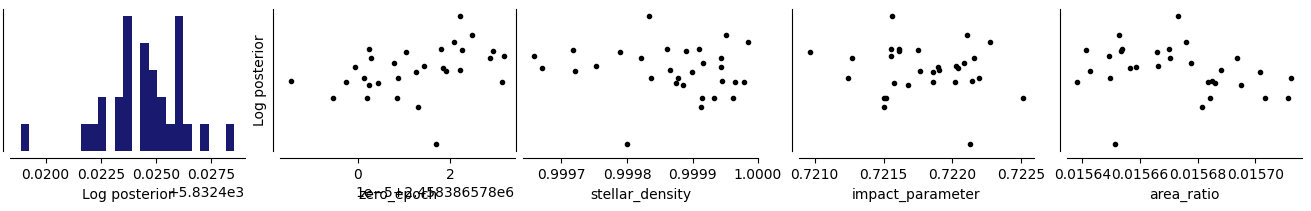

In [4]:
if not SMOKE_MODE:
    dir = os.listdir('./data/' + planet_name + '/mastDownload/TESS/')
    planet.de(datadir = './data/' + planet_name + '/mastDownload/TESS/' + dir[0] + '/')
    planet.fit_singles(use_cache=True, cache_path=f'cmat_cache/{planet_name}/fit_singles.dill')

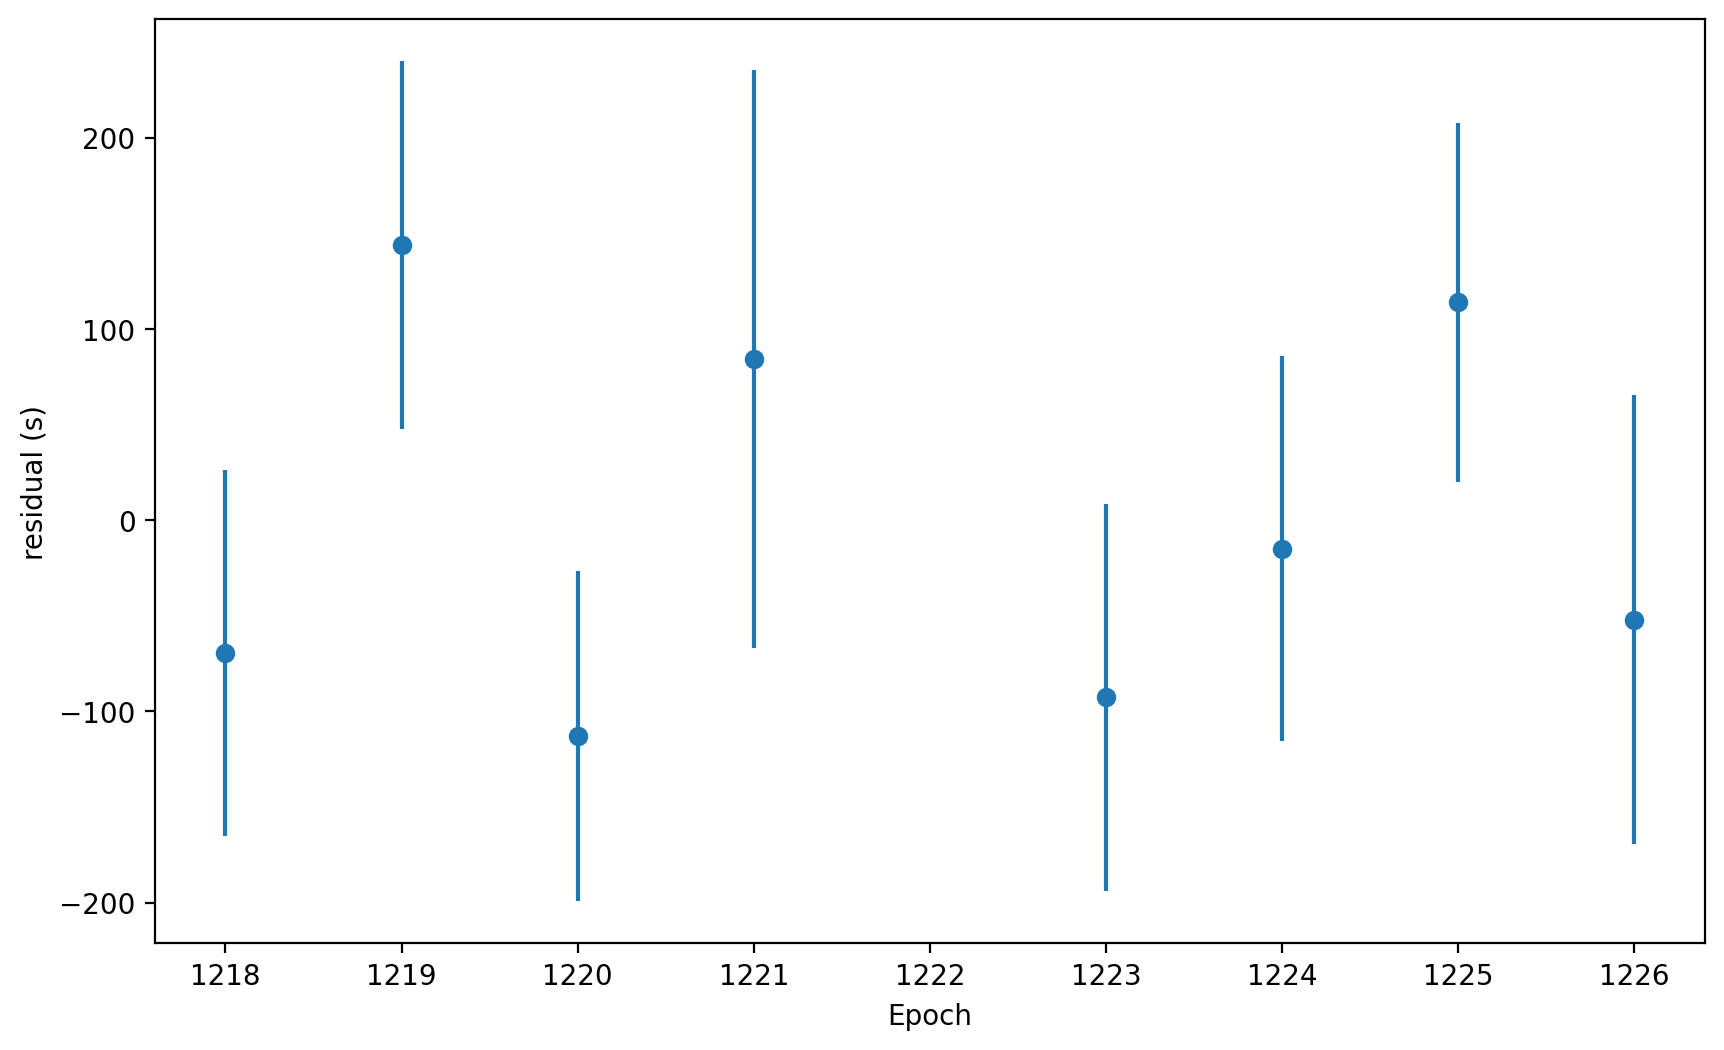

In [5]:
if not SMOKE_MODE:
    planet.calculate_ttv()
fig, ax = planet.plot_ttv_re()

# 4.Find m_crit

In [6]:
if SMOKE_MODE:
    rs = np.linspace(1.3, 1.7, 3)
    mp2s = np.array([5.0, 10.0, 20.0])
else:
    rs = np.linspace(0.1,4,100)
    mp2s = np.logspace(-2,5,200)

In [7]:
ttv_sim = cmat.TTVSimulation(epochs=planet.epochs,ttv_mcmc=planet.ttv_mcmc,ttv_err=planet.ttv_err,rs=rs,mp2s=mp2s,prop=planet.prop)

In [8]:
if SMOKE_MODE:
    smoke_parameters = [(r, mp2) for mp2 in mp2s for r in rs]
    rlt_ttv = np.array([ttv_sim.calculate_rebound(par) for par in smoke_parameters])
    ttv_sim.ttv_results = list(rlt_ttv)
    ttv_sim.ttv_rebound = rlt_ttv
else:
    import os
    rlt_ttv = ttv_sim.get_ttv_rebound_all(number_of_thread=6, use_cache=True, cache_path=f'cmat_cache/{planet_name}/ttv_grid.npz')
rlt_chi2, rlt_rms = ttv_sim.get_m_crit()
mass_thresholds = ttv_sim.get_mass_thresholds()
chi2_surface = ttv_sim.get_chi2_surface()
reduced_chi2_surface = ttv_sim.get_reduced_chi2_surface()
rms_surface = np.sqrt(np.mean(np.asarray(ttv_sim.ttv_results, dtype=float) ** 2, axis=1)).reshape(len(mp2s), len(rs))

def first_rejected_mass_curve(score_surface, threshold):
    curve = np.full(len(rs), np.nan)
    finite = np.isfinite(score_surface)
    for ratio_index in range(len(rs)):
        rejected = np.flatnonzero(finite[:, ratio_index] & (score_surface[:, ratio_index] >= threshold))
        if rejected.size:
            curve[ratio_index] = mp2s[rejected[0]]
    return curve

rlt_chi2_curve = first_rejected_mass_curve(chi2_surface, mass_thresholds.chi2_threshold)
rlt_rms_curve = first_rejected_mass_curve(rms_surface, mass_thresholds.rms_threshold)

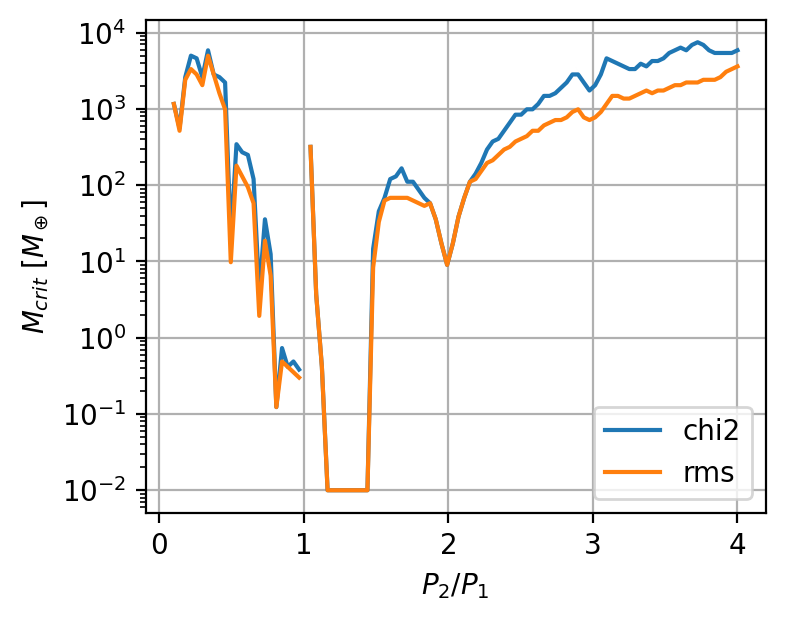

In [9]:
fig,ax = plt.subplots(figsize=(4,3.2),dpi=200)
ax.set_yscale('log')
# ax.set_xscale('log')
plt.grid()
plt.plot(rs,rlt_chi2_curve,label='chi2')
plt.plot(rs,rlt_rms_curve,label='rms')
# plt.vlines(3.3,0,20,linestyle='dashed',color='k')
# new_ticks = [1.5,2,2.5,3,3.3,3.5,4]
# plt.xticks(new_ticks)
plt.xlabel(r"$P_2/P_1$")
plt.ylabel(r"$M_{crit}$ [$M_\oplus$]")
plt.legend()

(<Figure size 800x640 with 2 Axes>,
 <Axes: xlabel='$P_2/P_1$', ylabel='Mass [$M_\\oplus$]'>)

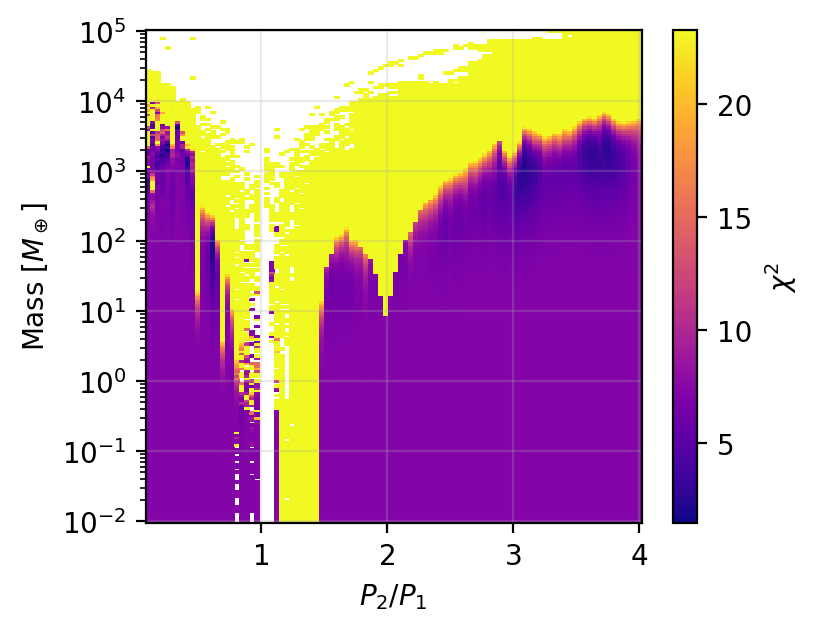

In [10]:
from cmat.plotting import score_surfaces as sp
fig, ax = plt.subplots(figsize=(4, 3.2), dpi=200)
sp.plot_score_surface(
    period_ratios=rs,
    companion_masses=mp2s,
    surface=chi2_surface,
    statistic_label="$\\chi^2$",
    vmin=None,
    vmax=mass_thresholds.chi2_threshold,
    threshold=None,
    show_threshold=True,
    threshold_color="white",
    levels=None,
    ax=ax,
    cmap="plasma",
    figsize=(4, 3.2),
    dpi=200,
)

# 5. Calculate MEGNO

In [11]:
if SMOKE_MODE:
    ttv_sim.megno_dt = 0.02
    ttv_sim.megno_runtime = 50.0
    megno_rlt = [ttv_sim.simulation_m((r, mp2)) for mp2 in mp2s for r in rs]
    ttv_sim.megno_results = megno_rlt
else:
    megno_rlt = ttv_sim.run_megno(number_of_threads=6, use_cache=True, cache_path=f'cmat_cache/{planet_name}/megno_grid.npz')

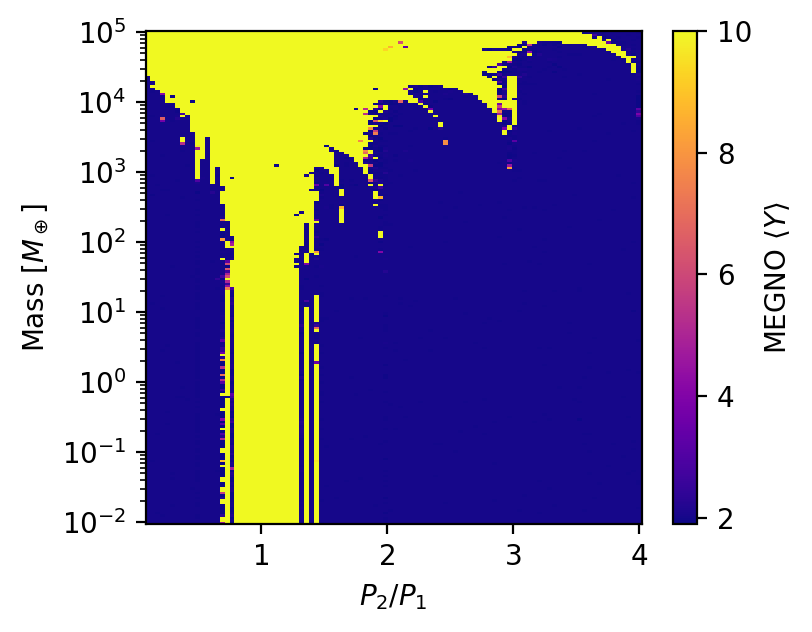

In [12]:
results2d = np.array(megno_rlt).reshape(len(mp2s),len(rs))
fig,ax = plt.subplots(figsize=(4,3.2),dpi=200)
X,Y = np.meshgrid(rs,mp2s)
ax.set_xlabel("$P_2/P_1$")
ax.set_ylabel("Mass [$M_\oplus$]")
# ax.set_xscale('log')
ax.set_yscale('log')
im = ax.pcolor(X,Y,results2d, vmin=1.9, vmax=10, cmap='plasma')
cb = plt.colorbar(im, ax=ax)
cb.set_label("MEGNO $\\langle Y \\rangle$")

# 6. Combined

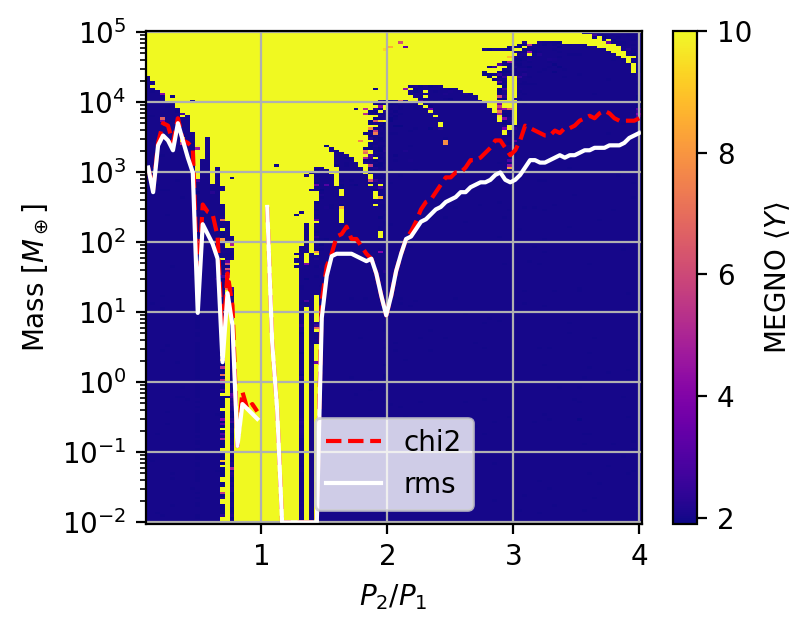

In [13]:
fig,ax = plt.subplots(figsize=(4,3.2),dpi=200)
X,Y = np.meshgrid(rs,mp2s)
ax.set_xlabel("$P_2/P_1$")
ax.set_ylabel("Mass [$M_\oplus$]")
ax.set_yscale('log')
im = ax.pcolor(X,Y,results2d, vmin=1.9, vmax=10, cmap='plasma')
cb = plt.colorbar(im, ax=ax)
cb.set_label("MEGNO $\\langle Y \\rangle$")
plt.grid()
plt.plot(rs,rlt_chi2_curve,'r--',label='chi2')
plt.plot(rs,rlt_rms_curve,'w',label='rms')
plt.legend()
plt.show()